# Level 3 — 불균형 대응 및 고급 Augmentation

**목표**: 다수 클래스의 정확도를 크게 희생하지 않으면서, 소수 클래스 (foggy / snowy / dawn-dusk) 의 성능을 끌어올립니다.

다음 축에서 **최소 2가지 이상** 의 기법을 적용하세요.
- Loss-level: Weighted CE, Focal Loss, LDAM, Class-Balanced Loss
- Sampling-level: class-balanced sampler
- Augmentation-level: RandAugment, Mixup, CutMix

Level 1 / 2 에서 가장 좋았던 백본을 base 로 사용하세요. wandb 를 사용하면 여러 기법의 비교 Run 을 같은 프로젝트에 모아 볼 수 있어 편리합니다.

In [4]:
import os
import sys

# # 1. 코랩 환경에서 레포지토리가 클론되지 않은 경우에만 Clone 진행
# repo_name = "2026-HYU-AUE8088-PA2"
# if not os.path.exists(f"/content/{repo_name}"):
#     !git clone https://github.com/IRCVLab/2026-HYU-AUE8088-PA2.git

# # 2. 작업 디렉토리를 레포지토리의 최상단(Root)으로 변경
# %cd /content/{repo_name}

# 프로젝트 루트를 sys.path에 추가 (src 모듈 인식용)
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2

# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r ../requirements.txt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import os, torch
import pandas as pd
import numpy as np

CKPT_DIR = "../checkpoints"

CKPT_MAP = {
    "VGG-16":              "level1_vgg16.pth",
    "ResNet-18":           "level1_resnet18.pth",
    "ResNet-50":           "level1_resnet50.pth",
    "ViT-S/16 scratch":   "level2_vit_s16.pth",
    "R18 w(1,1,1) e30":   "level1_r18_w1_1_1_e30.pth",
    "R18 w(2,1,1) e30":   "level1_r18_w2_1_1_e30.pth",
    "R18 w(1,3,1) e30":   "level1_r18_w1_3_1_e30.pth",
    "R18 w(1,1,2) e30":   "level1_r18_w1_1_2_e30.pth",
}

rows = []
for label, fname in CKPT_MAP.items():
    path = os.path.join(CKPT_DIR, fname)
    if not os.path.exists(path):
        continue
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    hist = ckpt.get("history")
    if hist is None:
        continue
    best = int(np.argmax(hist["val_avg_mf1"]))
    per  = hist["val_per_mf1"][best]
    rows.append({
        "Model":       label,
        "Avg-MF1":     round(hist["val_avg_mf1"][best], 4),
        "Weather":     round(per["weather"],   4),
        "Scene":       round(per["scene"],     4),
        "TimeOfDay":   round(per["timeofday"], 4),
        "Best Epoch":  best + 1,
        "Level":       fname.split("_")[0],
    })

df = (pd.DataFrame(rows)
        .set_index("Model")
        .sort_values("Avg-MF1", ascending=False))

print("=== Checkpoint Performance Summary ===")
display(df.style.highlight_max(subset=["Avg-MF1","Weather","Scene","TimeOfDay"],
                               color="lightgreen", axis=0))


=== Checkpoint Performance Summary ===


,Avg-MF1,Weather,Scene,TimeOfDay,Best Epoch,Level
Model,,,,,,
"R18 w(1,1,1) e30",0.658800,0.541000,0.619100,0.816300,27,level1
"R18 w(2,1,1) e30",0.656400,0.533300,0.598800,0.836900,28,level1
"R18 w(1,3,1) e30",0.647000,0.504200,0.611600,0.825300,30,level1
"R18 w(1,1,2) e30",0.640400,0.526100,0.616500,0.778500,28,level1
ResNet-50,0.634300,0.500600,0.610200,0.792000,25,level1
ResNet-18,0.634300,0.527600,0.568100,0.807100,28,level1
VGG-16,0.555100,0.381900,0.458900,0.824400,25,level1
ViT-S/16 scratch,0.548400,0.366000,0.453700,0.825300,23,level2


In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from src.utils.seed import set_seed, seed_worker
from src.utils.transforms import train_transform, eval_transform
from src.utils.trainer import MultiTaskTrainer, TrainConfig
from src.utils.wandb_logger import WandbLogger
from src.utils.metrics import collect_predictions, confusion_matrices, per_class_prf, CLASS_NAMES
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES
from src.datasets.samplers import class_balanced_sampler
from src.losses.imbalanced import FocalLoss, ClassBalancedLoss, LDAMLoss, weighted_cross_entropy
from src.augment.mix import mixup_data, cutmix_data, mixed_loss
from src.models.resnet import resnet18

SEED = 42
set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
import wandb; wandb.login()   # API key 입력

WANDB_PROJECT = "aue8088-pa2"   # 비활성화하려면 None
WANDB_TAGS    = ["level3"]
# 각 실험마다 RUN_NAME 만 바꿔서 동일 프로젝트에 누적하세요.
EXPERIMENT_NAME = "focal+sampler"

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jisang/.netrc.
wandb: Currently logged in as: journeyofbabo (journeyofbabo-hanyang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [8]:
DATA_ROOT = "../data/set_a"
BATCH = 64

# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------

train_ds = BDDAttrDataset(DATA_ROOT, "train", transform=train_transform())
val_ds   = BDDAttrDataset(DATA_ROOT, "val",   transform=eval_transform())

# 옵션 A — 가장 불균형이 심한 weather 속성 기준 class-balanced sampler 사용
sampler = class_balanced_sampler(train_ds, attribute="weather")
train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

데이터셋이 이미 존재합니다 → ../data/set_a


In [ ]:
# 옵션 B — 속성별로 다른 loss 적용. 가장 불균형이 심한 속성에 가장 강한 loss 사용.
samples_w = train_ds.class_counts("weather")
samples_s = train_ds.class_counts("scene")
samples_t = train_ds.class_counts("timeofday")

loss_fns = {
    "weather":   FocalLoss(gamma=2.0).to(device),
    "scene":     ClassBalancedLoss(samples_s).to(device),
    "timeofday": nn.CrossEntropyLoss(),
}

# Level 1 best checkpoint (R18 w(1,1,1) e30 = 0.6588) 로 초기화
model = resnet18().to(device)
ckpt = torch.load("../checkpoints/level1_r18_w1_1_1_e30.pth", map_location=device, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
print("Loaded Level 1 ResNet-18 checkpoint (Avg-MF1=0.6588)")

epochs = 25
optim  = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)
sched  = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)

logger = WandbLogger(
    project=WANDB_PROJECT,
    run_name=f"level3-{EXPERIMENT_NAME}",
    config={
        "backbone": "resnet18",
        "pretrained": "level1_r18_w1_1_1_e30",
        "sampler": "class_balanced(weather)",
        "loss": {"weather": "focal_g2.0", "scene": "cb_loss", "timeofday": "ce"},
        "epochs": epochs, "batch": BATCH, "lr": 3e-4, "seed": SEED,
    },
    tags=WANDB_TAGS + [EXPERIMENT_NAME],
)
trainer = MultiTaskTrainer(model, optim, sched, loss_fns, device, TrainConfig(epochs=epochs), logger=logger)

Loaded Level 1 ResNet-18 checkpoint (Avg-MF1=0.6588)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: WARNING Tried to log to step 1 that is less than the current step 25. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 2 that is less than the current step 25. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 3 that is less than the current step 25. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 4 that is less than the current step 25. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 5 that is less than the current step 25. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/

In [ ]:
# 옵션 C — 학습 루프에 Mixup/CutMix 를 통합하여 적용
# (깨끗한 실험을 위해서는 _train_one_epoch 를 서브클래싱하는 것이 좋으나,
#  아래는 augmented step 의 핵심만 인라인으로 보인 것입니다.)

from tqdm import tqdm

def step_with_mix(images, targets):
    """50% 확률로 Mixup, 나머지 50% 확률로 CutMix 적용."""
    if torch.rand(1).item() < 0.5:
        x, ya, yb, lam = mixup_data(images, targets, alpha=0.2)
    else:
        x, ya, yb, lam = cutmix_data(images, targets, alpha=1.0)
    logits = model(x)
    return mixed_loss(loss_fns, logits, ya, yb, lam)

# TODO: step_with_mix 와 trainer.evaluate() 를 사용하여 학습 루프를 작성하세요.
# 직접 작성한 학습 루프 안에서도 logger.log({...}, step=epoch) 로 매 epoch 메트릭을 wandb 에 보낼 수 있습니다.

history = {"train_loss": [], "val_avg_mf1": [], "val_per_mf1": []}

for epoch in range(epochs):
    model.train()
    total_loss = 0.0 
    for batch in tqdm(train_loader, desc=f"[epoch {epoch+1:02d}/{epochs}]", leave=False):
        images = batch["image"].to(device)
        targets = {a: batch[a].to(device) for a in ATTRIBUTES}

        optim.zero_grad(set_to_none=True)
        loss = step_with_mix(images, targets)
        loss.backward() 
        optim.step()
        total_loss += loss.item()

    sched.step()
    train_loss = total_loss / len(train_loader)
    val_metrics = trainer.evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_avg_mf1"].append(val_metrics["avg_macro_f1"])     
    history["val_per_mf1"].append(val_metrics["per_macro_f1"])     

    logger.log({"train/loss": train_loss,
               "val/avg_macro_f1": val_metrics["avg_macro_f1"],
               **{f"val/mf1_{a}": val_metrics["per_macro_f1"][a] for a in ATTRIBUTES}},
               step=epoch + 1)
    print(f"[epoch {epoch+1:02d}/{epochs}] loss={train_loss:.4f} val_avg_MF1={val_metrics['avg_macro_f1']:.4f} per={val_metrics['per_macro_f1']}")


os.makedirs("../checkpoints", exist_ok=True)
torch.save({"state_dict": model.state_dict(), "history": history},
           f"../checkpoints/level3_{EXPERIMENT_NAME}.pth")


[epoch 01/25] loss=1.5690 val_avg_MF1=0.6511 per={'weather': 0.5278818472440676, 'scene': 0.6395293320274179, 'timeofday': 0.7859946134245167}


[epoch 02/25] loss=1.4931 val_avg_MF1=0.6458 per={'weather': 0.5307370198401892, 'scene': 0.628280659908567, 'timeofday': 0.7783363108591073}


[epoch 03/25] loss=1.4791 val_avg_MF1=0.6434 per={'weather': 0.5292571980832167, 'scene': 0.6167150949158057, 'timeofday': 0.7841605753083823}


[epoch 04/25] loss=1.4076 val_avg_MF1=0.6308 per={'weather': 0.514482643143404, 'scene': 0.6036681225590693, 'timeofday': 0.7743511003875119}


[epoch 05/25] loss=1.5386 val_avg_MF1=0.6429 per={'weather': 0.5400174266061596, 'scene': 0.6233921953346414, 'timeofday': 0.7651600753295669}


...

[epoch 21/25] loss=1.6518 val_avg_MF1=0.6157 per={'weather': 0.4998661799109052, 'scene': 0.5659298621752503, 'timeofday': 0.7812003952400737}


[epoch 22/25] loss=1.4823 val_avg_MF1=0.5949 per={'weather': 0.4543415355166463, 'scene': 0.5616607720510537, 'timeofday': 0.7686757192853334}


[epoch 23/25] loss=1.5360 val_avg_MF1=0.5897 per={'weather': 0.43320887939429703, 'scene': 0.5412312168181899, 'timeofday': 0.7945907456693281}


[epoch 24/25] loss=1.3589 val_avg_MF1=0.6145 per={'weather': 0.46208029487542834, 'scene': 0.6104159425439987, 'timeofday': 0.770945033137488}


[epoch 25/25] loss=1.6661 val_avg_MF1=0.6056 per={'weather': 0.4723842505636026, 'scene': 0.5928045301877077, 'timeofday': 0.7515112413103625}


In [14]:
# 학습 종료 후 — 속성별 confusion matrix + per-class F1 표를 wandb 에 업로드
val_pred, _, val_tgt, _ = collect_predictions(model, val_loader, device)
cms = confusion_matrices(val_pred, val_tgt)
prf = per_class_prf(val_pred, val_tgt)
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"final/cm_{a}", cms[a], CLASS_NAMES[a])
    rows = list(zip(prf[a]["class"], prf[a]["precision"], prf[a]["recall"], prf[a]["f1"], prf[a]["support"]))
    logger.log_table(f"final/prf_{a}", ["class", "P", "R", "F1", "support"], [list(r) for r in rows])
logger.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


train/loss,█▇▆█▇▆▅▅▆▅▆▅▆▄▃▄▃▃▂▃▁▁▂▃▄
val/avg_macro_f1,▅▁▅▅▅▅▆▆▅▆▆▅▇▇▅▇█▇▆▇██▇▇▅
val/mf1_scene,▆▁▄▇▅▃▇▆▃▅▇▄██▆██▇▇▇████▆
val/mf1_timeofday,▄▁▄▃▂▇▂▆█▆█▅▆▅▆▆█▅▂▇▅▆▆▅▂
val/mf1_weather,▄▁▅▄▆▆▆▇▆▇▄▆▄▆▄▇▇▇▇▇▇█▇█▅
train/loss,1.66613
val/avg_macro_f1,0.60557
val/mf1_scene,0.5928
val/mf1_timeofday,0.75151
val/mf1_weather,0.47238


## 분석 (필수)

각 기법에 대해 **속성별 per-class F1 표** 를 작성하세요. 다음 항목을 강조해 주세요.
- 소수 클래스 (foggy / snowy / dawn-dusk) 의 적용 전후 성능 차이.
- 다수 클래스의 회귀 (regression) 발생 여부 — 그 trade-off 가 정당한지 논거.
- Sampling 과 Mixup / CutMix 의 상호작용 — 서로 도움이 되는지 충돌하는지.

Evaluating Baseline (R18 w(1,1,1) e30) ...
Evaluating Level 3 (focal+sampler+mix) ...

=== Per-class F1 Comparison ===

── WEATHER ──


,"Baseline (R18 w(1,1,1) e30)",Level 3 (focal+sampler+mix),Δ F1
Class,,,
clear,0.8837,0.7809,-0.1028
overcast,0.6296,0.6195,-0.0101
rainy,0.6588,0.4583,-0.2005
snowy,0.4722,0.4156,-0.0566
foggy,0.0000,0.0000,0.0000
partly cloudy,0.5778,0.5600,-0.0178



── SCENE ──


,"Baseline (R18 w(1,1,1) e30)",Level 3 (focal+sampler+mix),Δ F1
Class,,,
city street,0.8131,0.7316,-0.0815
highway,0.6667,0.6169,-0.0498
residential,0.3784,0.4299,0.0515



── TIMEOFDAY ──


,"Baseline (R18 w(1,1,1) e30)",Level 3 (focal+sampler+mix),Δ F1
Class,,,
daytime,0.9372,0.9424,0.0052
night,0.9830,0.9788,-0.0042
dawn/dusk,0.4615,0.3333,-0.1282


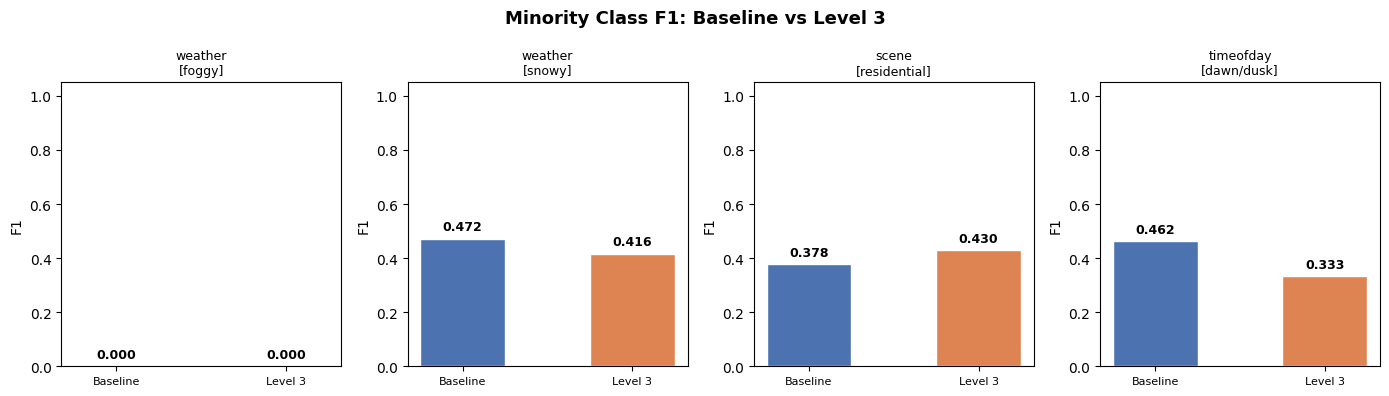

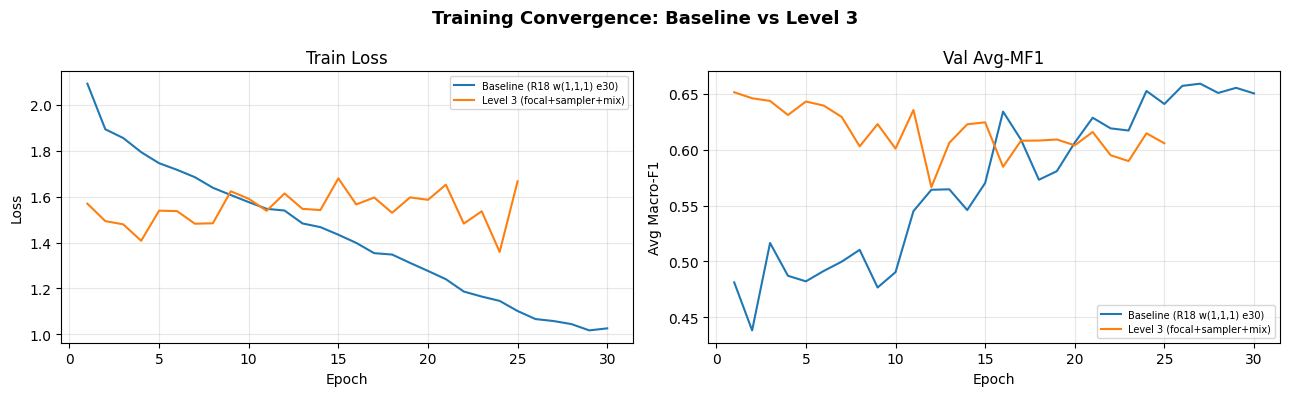


=== Overall Summary ===


,Best Avg-MF1,Weather,Scene,TimeOfDay
Model,,,,
"Baseline (R18 w(1,1,1) e30)",0.658800,0.541000,0.619100,0.816300
Level 3 (focal+sampler+mix),0.651100,0.527900,0.639500,0.786000


In [15]:
import os, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader
from src.utils.transforms import eval_transform
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES
from src.utils.metrics import collect_predictions, per_class_prf, CLASS_NAMES
from src.models.resnet import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = "../checkpoints"
DATA_ROOT = "../data/set_a"

# --- 비교할 체크포인트 ---
COMPARE = {
    "Baseline (R18 w(1,1,1) e30)": "level1_r18_w1_1_1_e30.pth",
    "Level 3 (focal+sampler+mix)":  "level3_focal+sampler.pth",
}

# --- val loader ---
val_ds     = BDDAttrDataset(DATA_ROOT, "val", transform=eval_transform())
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

def load_model_prf(ckpt_path):
    model = resnet18().to(device)
    ckpt  = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    preds, _, tgts, _ = collect_predictions(model, val_loader, device)
    history = ckpt.get("history")
    return per_class_prf(preds, tgts), history

results = {}
for label, fname in COMPARE.items():
    path = os.path.join(CKPT_DIR, fname)
    if not os.path.exists(path):
        print(f"[SKIP] {fname} not found"); continue
    print(f"Evaluating {label} ...")
    results[label] = load_model_prf(path)

labels = list(results.keys())

# ── 1. Per-class F1 table (per attribute) ──────────────────────────────────
MINORITY = {
    "weather":   {"foggy", "snowy"},
    "scene":     {"residential"},
    "timeofday": {"dawn/dusk"},
}

print("\n=== Per-class F1 Comparison ===")
for attr in ATTRIBUTES:
    rows = []
    classes = CLASS_NAMES[attr]
    for cls in classes:
        row = {"Class": cls}
        for lbl in labels:
            prf = results[lbl][0]
            idx = prf[attr]["class"].index(cls)
            row[lbl] = round(prf[attr]["f1"][idx], 4)
        if len(labels) == 2:
            row["Δ F1"] = round(row[labels[1]] - row[labels[0]], 4)
        rows.append(row)
    df = pd.DataFrame(rows).set_index("Class")
    
    # highlight minority classes
    minority = MINORITY[attr]
    def highlight(row):
        color = "background-color: #fff3cd" if row.name in minority else ""
        return [color] * len(row)
    
    print(f"\n── {attr.upper()} ──")
    display(df.style
              .apply(highlight, axis=1)
              .highlight_max(subset=[c for c in df.columns if c != "Δ F1"],
                             color="lightgreen", axis=0)
              .highlight_min(subset=[c for c in df.columns if c != "Δ F1"],
                             color="#ffcccc",   axis=0)
              .format("{:.4f}"))

# ── 2. Minority class bar chart ─────────────────────────────────────────────
MINORITY_CLASSES = [
    ("weather",   "foggy"),
    ("weather",   "snowy"),
    ("scene",     "residential"),
    ("timeofday", "dawn/dusk"),
]

fig, axes = plt.subplots(1, len(MINORITY_CLASSES), figsize=(14, 4))
fig.suptitle("Minority Class F1: Baseline vs Level 3", fontsize=13, fontweight="bold")

colors = ["#4c72b0", "#dd8452"]
for ax, (attr, cls) in zip(axes, MINORITY_CLASSES):
    vals = []
    for lbl in labels:
        prf = results[lbl][0]
        if cls in prf[attr]["class"]:
            idx = prf[attr]["class"].index(cls)
            vals.append(prf[attr]["f1"][idx])
        else:
            vals.append(0.0)
    bars = ax.bar(range(len(labels)), vals, color=colors[:len(labels)], width=0.5, edgecolor="white")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([l.split("(")[0].strip() for l in labels], fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{attr}\n[{cls}]", fontsize=9)
    ax.set_ylabel("F1")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "level3_minority_f1.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Convergence comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training Convergence: Baseline vs Level 3", fontsize=13, fontweight="bold")

for lbl, (prf_data, history) in results.items():
    if history is None:
        continue
    epochs = range(1, len(history["val_avg_mf1"]) + 1)
    axes[0].plot(epochs, history["train_loss"],    label=lbl, linewidth=1.5)
    axes[1].plot(epochs, history["val_avg_mf1"],   label=lbl, linewidth=1.5)

axes[0].set_title("Train Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Val Avg-MF1"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Avg Macro-F1")
for ax in axes:
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "level3_convergence.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Summary table ─────────────────────────────────────────────────────────
print("\n=== Overall Summary ===")
summary_rows = []
for lbl, (prf_data, history) in results.items():
    best_mf1 = max(history["val_avg_mf1"]) if history else float("nan")
    per_best  = history["val_per_mf1"][int(np.argmax(history["val_avg_mf1"]))] if history else {}
    summary_rows.append({
        "Model":     lbl,
        "Best Avg-MF1": round(best_mf1, 4),
        "Weather":   round(per_best.get("weather",   float("nan")), 4),
        "Scene":     round(per_best.get("scene",     float("nan")), 4),
        "TimeOfDay": round(per_best.get("timeofday", float("nan")), 4),
    })
df_sum = pd.DataFrame(summary_rows).set_index("Model")
display(df_sum.style.highlight_max(color="lightgreen", axis=0))



  Ablation: low_lr  (focal=False, sampler=False, mix=none)


  [01/15] loss=1.0963  val_avg_MF1=0.6430  per={'weather': 0.5335537853721518, 'scene': 0.6238384473678591, 'timeofday': 0.7717519753787127}


  [02/15] loss=1.0785  val_avg_MF1=0.6244  per={'weather': 0.49179856135501293, 'scene': 0.5588441188441188, 'timeofday': 0.8224545475388036}


  [03/15] loss=1.0633  val_avg_MF1=0.6572  per={'weather': 0.5606481606508283, 'scene': 0.6129094055362208, 'timeofday': 0.7979601835996424}


  [04/15] loss=1.0407  val_avg_MF1=0.6485  per={'weather': 0.5209047329915051, 'scene': 0.6144731715713069, 'timeofday': 0.8102438957620839}


...

  [12/15] loss=1.8800  val_avg_MF1=0.6249  per={'weather': 0.5280298112990527, 'scene': 0.5917693169092945, 'timeofday': 0.7547597375706577}


  [13/15] loss=1.9199  val_avg_MF1=0.6392  per={'weather': 0.5155737266848378, 'scene': 0.6081640070006323, 'timeofday': 0.7938778451937929}


  [14/15] loss=1.9799  val_avg_MF1=0.6307  per={'weather': 0.5075488595783865, 'scene': 0.6050623693340579, 'timeofday': 0.7796217574383077}


  [15/15] loss=1.9279  val_avg_MF1=0.6402  per={'weather': 0.5132259096991838, 'scene': 0.6136371480893792, 'timeofday': 0.7938778451937929}
  Saved → ../checkpoints/level3_ablation_focal+sampler+cutmix.pth

=== Ablation Summary ===


,Best Avg-MF1,Weather,Scene,TimeOfDay,Best Epoch
Config,,,,,
"Baseline (LR=3e-4, 30ep)",0.658800,0.541000,0.619100,0.816300,27
low_lr,0.657200,0.560600,0.612900,0.798000,3
focal,0.654600,0.535700,0.626600,0.801500,12
focal+sampler,0.656400,0.527700,0.628100,0.813600,14
focal+sampler+mixup,0.662700,0.533900,0.626000,0.828000,14
focal+sampler+cutmix,0.644500,0.530700,0.623300,0.779600,10


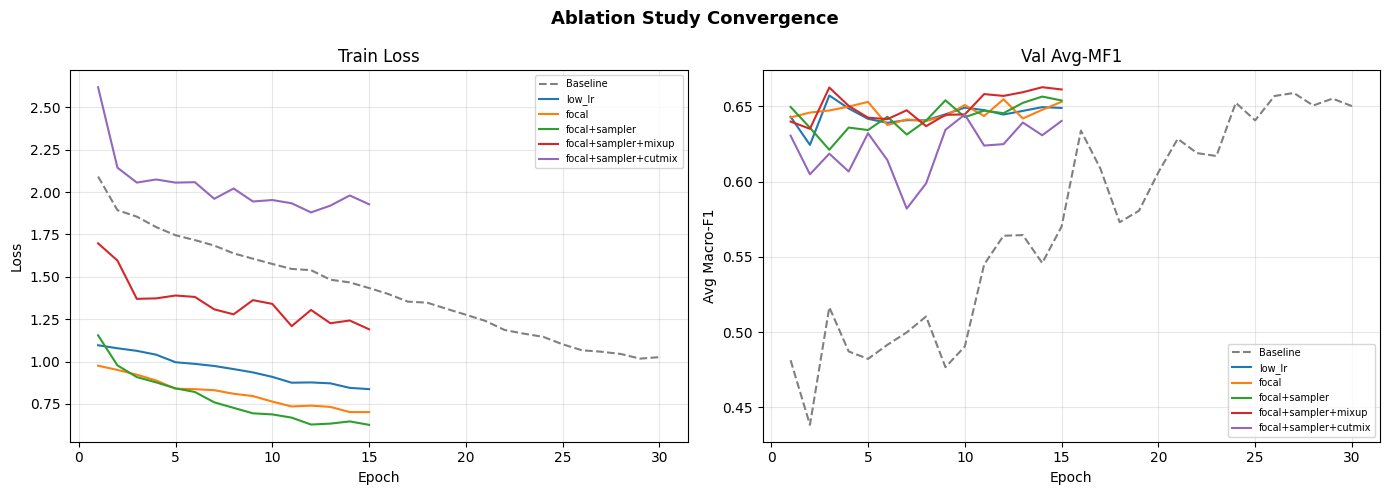

In [16]:
"""
Ablation Study — 5 combinations (each adds one technique)
  1. low_lr          : CE loss, no sampler, no mix,  lr=5e-5
  2. focal           : Focal,   no sampler, no mix,  lr=5e-5
  3. focal+sampler   : Focal,   sampler,    no mix,  lr=5e-5
  4. focal+sampler+mixup   : Focal, sampler, Mixup,  lr=5e-5
  5. focal+sampler+cutmix  : Focal, sampler, CutMix, lr=5e-5
All start from the same Level 1 checkpoint (Avg-MF1=0.6588).
"""
import os, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.utils.seed import set_seed, seed_worker
from src.utils.transforms import train_transform, eval_transform
from src.utils.trainer import MultiTaskTrainer, TrainConfig
from src.utils.metrics import collect_predictions, per_class_prf, CLASS_NAMES
from src.utils.wandb_logger import WandbLogger
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES
from src.datasets.samplers import class_balanced_sampler
from src.losses.imbalanced import FocalLoss, ClassBalancedLoss
from src.augment.mix import mixup_data, cutmix_data, mixed_loss
from src.models.resnet import resnet18

SEED = 42
set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR   = "../checkpoints"
DATA_ROOT  = "../data/set_a"
BASE_CKPT  = os.path.join(CKPT_DIR, "level1_r18_w1_1_1_e30.pth")
ABL_EPOCHS = 15
BATCH      = 64
LR         = 5e-5

ABLATIONS = [
    dict(name="low_lr",               use_focal=False, use_sampler=False, mix="none"),
    dict(name="focal",                use_focal=True,  use_sampler=False, mix="none"),
    dict(name="focal+sampler",        use_focal=True,  use_sampler=True,  mix="none"),
    dict(name="focal+sampler+mixup",  use_focal=True,  use_sampler=True,  mix="mixup"),
    dict(name="focal+sampler+cutmix", use_focal=True,  use_sampler=True,  mix="cutmix"),
]

# ── datasets (shared) ────────────────────────────────────────────────────────
train_ds = BDDAttrDataset(DATA_ROOT, "train", transform=train_transform())
val_ds   = BDDAttrDataset(DATA_ROOT, "val",   transform=eval_transform())
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)

samples_w = train_ds.class_counts("weather")
samples_s = train_ds.class_counts("scene")

# ── training helper ──────────────────────────────────────────────────────────
def run_ablation(cfg):
    tag = f"ablation_{cfg['name']}"
    out_path = os.path.join(CKPT_DIR, f"level3_{tag}.pth")
    if os.path.exists(out_path):
        print(f"[SKIP] {tag} already trained → {out_path}")
        ckpt = torch.load(out_path, map_location="cpu", weights_only=False)
        return ckpt["history"]

    print(f"\n{'='*60}")
    print(f"  Ablation: {cfg['name']}  (focal={cfg['use_focal']}, sampler={cfg['use_sampler']}, mix={cfg['mix']})")
    print(f"{'='*60}")

    # Model — reload baseline every run
    set_seed(SEED, deterministic=True)
    model = resnet18().to(device)
    base  = torch.load(BASE_CKPT, map_location=device, weights_only=False)
    model.load_state_dict(base["state_dict"])

    # DataLoader
    if cfg["use_sampler"]:
        sampler  = class_balanced_sampler(train_ds, attribute="weather")
        loader   = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                              num_workers=2, pin_memory=True)
    else:
        loader   = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                              num_workers=2, pin_memory=True,
                              worker_init_fn=seed_worker)

    # Loss functions
    if cfg["use_focal"]:
        loss_fns = {
            "weather":   FocalLoss(gamma=2.0).to(device),
            "scene":     ClassBalancedLoss(samples_s).to(device),
            "timeofday": nn.CrossEntropyLoss(),
        }
    else:
        loss_fns = {a: nn.CrossEntropyLoss() for a in ATTRIBUTES}

    optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=ABL_EPOCHS)

    trainer = MultiTaskTrainer(model, optim, sched, loss_fns, device,
                               TrainConfig(epochs=ABL_EPOCHS))

    history = {"train_loss": [], "val_avg_mf1": [], "val_per_mf1": []}

    for epoch in range(ABL_EPOCHS):
        model.train()
        total_loss = 0.0
        for batch in tqdm(loader, desc=f"  [{epoch+1:02d}/{ABL_EPOCHS}]", leave=False):
            images  = batch["image"].to(device)
            targets = {a: batch[a].to(device) for a in ATTRIBUTES}
            optim.zero_grad(set_to_none=True)

            if cfg["mix"] == "mixup":
                x, ya, yb, lam = mixup_data(images, targets, alpha=0.2)
                loss = mixed_loss(loss_fns, model(x), ya, yb, lam)
            elif cfg["mix"] == "cutmix":
                x, ya, yb, lam = cutmix_data(images, targets, alpha=1.0)
                loss = mixed_loss(loss_fns, model(x), ya, yb, lam)
            else:
                logits = model(images)
                loss   = sum(loss_fns[a](logits[a], targets[a]) for a in ATTRIBUTES)

            loss.backward()
            optim.step()
            total_loss += loss.item()

        sched.step()
        train_loss  = total_loss / len(loader)
        val_metrics = trainer.evaluate(val_loader)
        history["train_loss"].append(train_loss)
        history["val_avg_mf1"].append(val_metrics["avg_macro_f1"])
        history["val_per_mf1"].append(val_metrics["per_macro_f1"])
        print(f"  [{epoch+1:02d}/{ABL_EPOCHS}] loss={train_loss:.4f}  val_avg_MF1={val_metrics['avg_macro_f1']:.4f}  per={val_metrics['per_macro_f1']}")

    torch.save({"state_dict": model.state_dict(), "history": history}, out_path)
    print(f"  Saved → {out_path}")
    return history

# ── run all ──────────────────────────────────────────────────────────────────
abl_histories = {}
for cfg in ABLATIONS:
    abl_histories[cfg["name"]] = run_ablation(cfg)

# ── comparison table ──────────────────────────────────────────────────────────
print("\n=== Ablation Summary ===")
rows = []
baseline_ckpt = torch.load(BASE_CKPT, map_location="cpu", weights_only=False)
b_hist = baseline_ckpt["history"]
b_best = int(np.argmax(b_hist["val_avg_mf1"]))
b_per  = b_hist["val_per_mf1"][b_best]
rows.append({"Config": "Baseline (LR=3e-4, 30ep)",
             "Best Avg-MF1": round(b_hist["val_avg_mf1"][b_best], 4),
             "Weather":   round(b_per["weather"],   4),
             "Scene":     round(b_per["scene"],     4),
             "TimeOfDay": round(b_per["timeofday"], 4),
             "Best Epoch": b_best + 1})

for cfg in ABLATIONS:
    hist = abl_histories[cfg["name"]]
    best = int(np.argmax(hist["val_avg_mf1"]))
    per  = hist["val_per_mf1"][best]
    rows.append({"Config": cfg["name"],
                 "Best Avg-MF1": round(hist["val_avg_mf1"][best], 4),
                 "Weather":   round(per["weather"],   4),
                 "Scene":     round(per["scene"],     4),
                 "TimeOfDay": round(per["timeofday"], 4),
                 "Best Epoch": best + 1})

df_abl = pd.DataFrame(rows).set_index("Config")
display(df_abl.style.highlight_max(subset=["Best Avg-MF1","Weather","Scene","TimeOfDay"],
                                   color="lightgreen", axis=0))

# ── convergence plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ablation Study Convergence", fontsize=13, fontweight="bold")

# baseline (30 ep) as reference
axes[0].plot(range(1, len(b_hist["train_loss"])+1),  b_hist["train_loss"],  label="Baseline", linestyle="--", color="gray")
axes[1].plot(range(1, len(b_hist["val_avg_mf1"])+1), b_hist["val_avg_mf1"], label="Baseline", linestyle="--", color="gray")

for cfg in ABLATIONS:
    hist = abl_histories[cfg["name"]]
    ep = range(1, len(hist["val_avg_mf1"])+1)
    axes[0].plot(ep, hist["train_loss"],  label=cfg["name"], linewidth=1.5)
    axes[1].plot(ep, hist["val_avg_mf1"], label=cfg["name"], linewidth=1.5)

axes[0].set_title("Train Loss");    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Val Avg-MF1");   axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Avg Macro-F1")
for ax in axes:
    ax.legend(fontsize=7, loc="best"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "level3_ablation_convergence.png"), dpi=150, bbox_inches="tight")
plt.show()


Loaded baseline checkpoint (Avg-MF1=0.6588)


[01/30] loss=1.6974  val_avg_MF1=0.6398  per={'weather': 0.5124014023205108, 'scene': 0.6021977457463926, 'timeofday': 0.8049425838412895}


[02/30] loss=1.5962  val_avg_MF1=0.6344  per={'weather': 0.519346226332408, 'scene': 0.6116019832310916, 'timeofday': 0.7721950534195896}


[03/30] loss=1.3707  val_avg_MF1=0.6626  per={'weather': 0.5289746946093695, 'scene': 0.6520731178320118, 'timeofday': 0.8067737401801889}


[04/30] loss=1.3756  val_avg_MF1=0.6513  per={'weather': 0.530295698066873, 'scene': 0.6097345845779382, 'timeofday': 0.8139523956360218}


...

[28/30] loss=1.2689  val_avg_MF1=0.6455  per={'weather': 0.524207468326677, 'scene': 0.6131022278941797, 'timeofday': 0.799109842942152}


[29/30] loss=1.1215  val_avg_MF1=0.6369  per={'weather': 0.511255185837334, 'scene': 0.6127730773211771, 'timeofday': 0.7866918076257852}


[30/30] loss=1.0523  val_avg_MF1=0.6590  per={'weather': 0.519290136152359, 'scene': 0.6309899162236792, 'timeofday': 0.8266501795913562}

Saved → ../checkpoints/level3_best_30ep.pth
Best  → epoch 03  Avg-MF1=0.6626  per={'weather': 0.5289746946093695, 'scene': 0.6520731178320118, 'timeofday': 0.8067737401801889}


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


train/loss,█▇▄▅▅▅▄▄▄▄▃▄▃▃▂▄▁▂▃▃▄▁▁▁▂▂▂▃▂▁
val/avg_macro_f1,▄▃█▆▃▄▅▃▂▃▇▇▃▁▃▆▄▁▂▄▆▅▆▅▅▄▅▅▃▇
val/mf1_scene,▄▅█▄▃▂▃▃▁▂▅▄▃▁▄▅▄▃▂▄▆▅▅▅▅▄▄▅▅▆
val/mf1_timeofday,▄▁▅▅▄▆▆▄▅▅██▃▅▂▅▄▂▅▄▄▄▄▄▅▅▅▄▃▇
val/mf1_weather,▃▅▆▇▄▅█▄▂▂▄▇▅▁▄▅▆▂▃▄▅▆▇▄▅▄▅▅▃▅
train/loss,1.05234
val/avg_macro_f1,0.65898
val/mf1_scene,0.63099
val/mf1_timeofday,0.82665
val/mf1_weather,0.51929


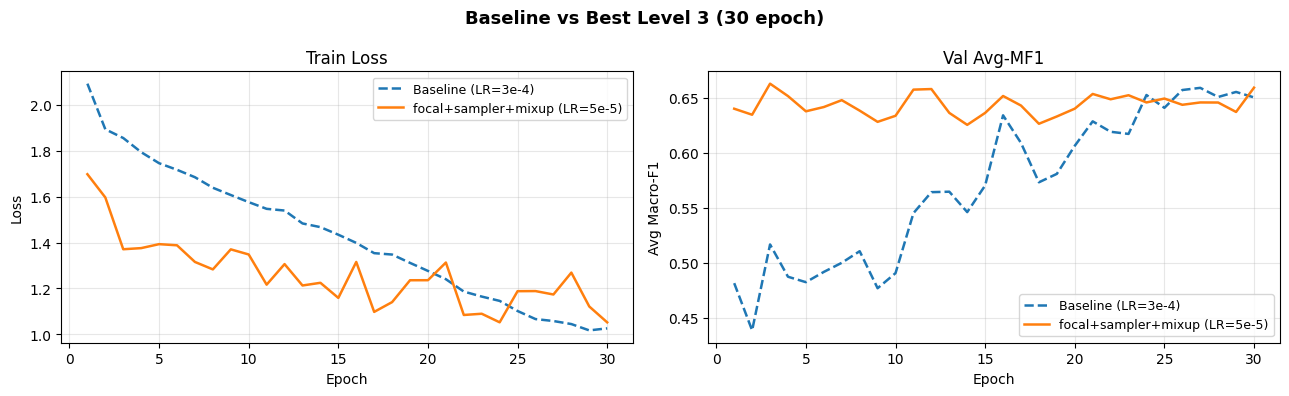

,Best Avg-MF1,Weather,Scene,TimeOfDay,Best Epoch
Config,,,,,
"Baseline (LR=3e-4, 30ep)",0.658800,0.541000,0.619100,0.816300,27
"focal+sampler+mixup (LR=5e-5, 30ep)",0.662600,0.529000,0.652100,0.806800,3


: 

In [ ]:
"""
Best config (focal+sampler+mixup, LR=5e-5) — 30 epoch full run
Compare against Baseline (R18 w(1,1,1) e30, LR=3e-4).
"""
import os, torch, wandb
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.utils.seed import set_seed
from src.utils.transforms import train_transform, eval_transform
from src.utils.trainer import MultiTaskTrainer, TrainConfig
from src.utils.wandb_logger import WandbLogger
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES
from src.datasets.samplers import class_balanced_sampler
from src.losses.imbalanced import FocalLoss, ClassBalancedLoss
from src.augment.mix import mixup_data, mixed_loss
from src.models.resnet import resnet18

SEED       = 42
EPOCHS     = 30
BATCH      = 64
LR         = 5e-5
CKPT_DIR   = "../checkpoints"
DATA_ROOT  = "../data/set_a"
BASE_CKPT  = os.path.join(CKPT_DIR, "level1_r18_w1_1_1_e30.pth")
OUT_CKPT   = os.path.join(CKPT_DIR, "level3_best_30ep.pth")
EXP_NAME   = "focal+sampler+mixup_30ep"

set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── data ─────────────────────────────────────────────────────────────────────
train_ds   = BDDAttrDataset(DATA_ROOT, "train", transform=train_transform())
val_ds     = BDDAttrDataset(DATA_ROOT, "val",   transform=eval_transform())
sampler    = class_balanced_sampler(train_ds, attribute="weather")
train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── model — start from Level 1 best ──────────────────────────────────────────
model = resnet18().to(device)
base  = torch.load(BASE_CKPT, map_location=device, weights_only=False)
model.load_state_dict(base["state_dict"])
print(f"Loaded baseline checkpoint (Avg-MF1=0.6588)")

# ── loss, optim, sched ────────────────────────────────────────────────────────
samples_s = train_ds.class_counts("scene")
loss_fns  = {
    "weather":   FocalLoss(gamma=2.0).to(device),
    "scene":     ClassBalancedLoss(samples_s).to(device),
    "timeofday": nn.CrossEntropyLoss(),
}
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS)

# ── wandb ─────────────────────────────────────────────────────────────────────
logger = WandbLogger(
    project="aue8088-pa2",
    run_name=f"level3-{EXP_NAME}",
    config={
        "backbone": "resnet18",
        "pretrained": "level1_r18_w1_1_1_e30",
        "loss": {"weather": "focal_g2.0", "scene": "cb_loss", "timeofday": "ce"},
        "sampler": "class_balanced(weather)",
        "augment": "mixup_alpha0.2",
        "epochs": EPOCHS, "batch": BATCH, "lr": LR, "seed": SEED,
    },
    tags=["level3", EXP_NAME],
)
trainer = MultiTaskTrainer(model, optim, sched, loss_fns, device,
                           TrainConfig(epochs=EPOCHS), logger=logger)

# ── training loop ─────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_avg_mf1": [], "val_per_mf1": []}

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for batch in tqdm(train_loader, desc=f"[{epoch+1:02d}/{EPOCHS}]", leave=False):
        images  = batch["image"].to(device)
        targets = {a: batch[a].to(device) for a in ATTRIBUTES}
        optim.zero_grad(set_to_none=True)
        x, ya, yb, lam = mixup_data(images, targets, alpha=0.2)
        loss = mixed_loss(loss_fns, model(x), ya, yb, lam)
        loss.backward()
        optim.step()
        total_loss += loss.item()

    sched.step()
    train_loss  = total_loss / len(train_loader)
    val_metrics = trainer.evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_avg_mf1"].append(val_metrics["avg_macro_f1"])
    history["val_per_mf1"].append(val_metrics["per_macro_f1"])

    logger.log({
        "train/loss": train_loss,
        "val/avg_macro_f1": val_metrics["avg_macro_f1"],
        **{f"val/mf1_{a}": val_metrics["per_macro_f1"][a] for a in ATTRIBUTES},
    }, step=epoch + 1)
    print(f"[{epoch+1:02d}/{EPOCHS}] loss={train_loss:.4f}  val_avg_MF1={val_metrics['avg_macro_f1']:.4f}  per={val_metrics['per_macro_f1']}")

# ── save ──────────────────────────────────────────────────────────────────────
os.makedirs(CKPT_DIR, exist_ok=True)
torch.save({"state_dict": model.state_dict(), "history": history}, OUT_CKPT)
print(f"\nSaved → {OUT_CKPT}")

best_ep  = int(np.argmax(history["val_avg_mf1"]))
best_mf1 = history["val_avg_mf1"][best_ep]
best_per = history["val_per_mf1"][best_ep]
print(f"Best  → epoch {best_ep+1:02d}  Avg-MF1={best_mf1:.4f}  per={best_per}")

# ── wandb confusion matrix + per-class table ──────────────────────────────────
from src.utils.metrics import collect_predictions, confusion_matrices, per_class_prf, CLASS_NAMES
val_pred, _, val_tgt, _ = collect_predictions(model, val_loader, device)
cms = confusion_matrices(val_pred, val_tgt)
prf = per_class_prf(val_pred, val_tgt)
for a in ATTRIBUTES:
    logger.log_confusion_matrix(f"final/cm_{a}", cms[a], CLASS_NAMES[a])
    rows = list(zip(prf[a]["class"], prf[a]["precision"], prf[a]["recall"], prf[a]["f1"], prf[a]["support"]))
    logger.log_table(f"final/prf_{a}", ["class", "P", "R", "F1", "support"], [list(r) for r in rows])
logger.finish()

# ── quick comparison vs baseline ──────────────────────────────────────────────
import pandas as pd
b_hist  = torch.load(BASE_CKPT, map_location="cpu", weights_only=False)["history"]
b_best  = int(np.argmax(b_hist["val_avg_mf1"]))
b_per   = b_hist["val_per_mf1"][b_best]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Baseline vs Best Level 3 (30 epoch)", fontsize=13, fontweight="bold")

for label, hist, ls in [
    ("Baseline (LR=3e-4)", b_hist, "--"),
    (f"focal+sampler+mixup (LR=5e-5)", history, "-"),
]:
    ep = range(1, len(hist["val_avg_mf1"]) + 1)
    axes[0].plot(ep, hist["train_loss"],  label=label, linestyle=ls, linewidth=1.8)
    axes[1].plot(ep, hist["val_avg_mf1"], label=label, linestyle=ls, linewidth=1.8)

axes[0].set_title("Train Loss");   axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Val Avg-MF1"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Avg Macro-F1")
for ax in axes:
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "level3_best30_vs_baseline.png"), dpi=150, bbox_inches="tight")
plt.show()

rows = [
    {"Config": "Baseline (LR=3e-4, 30ep)",
     "Best Avg-MF1": round(b_hist["val_avg_mf1"][b_best], 4),
     "Weather": round(b_per["weather"], 4), "Scene": round(b_per["scene"], 4),
     "TimeOfDay": round(b_per["timeofday"], 4), "Best Epoch": b_best + 1},
    {"Config": f"focal+sampler+mixup (LR=5e-5, 30ep)",
     "Best Avg-MF1": round(best_mf1, 4),
     "Weather": round(best_per["weather"], 4), "Scene": round(best_per["scene"], 4),
     "TimeOfDay": round(best_per["timeofday"], 4), "Best Epoch": best_ep + 1},
]
df = pd.DataFrame(rows).set_index("Config")
display(df.style.highlight_max(color="lightgreen", axis=0))
